In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
data = 'course_lead_scoring.csv'

In [9]:
df = pd.read_csv(data)

In [10]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [11]:
df.isna().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [12]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']
numerical = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']

df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0.0)

In [13]:
df.dtypes

lead_source                     str
industry                        str
number_of_courses_viewed      int64
annual_income               float64
employment_status               str
location                        str
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [14]:
df.nunique()

lead_source                    6
industry                       8
number_of_courses_viewed      10
annual_income               1268
employment_status              5
location                       8
interaction_count             12
lead_score                   101
converted                      2
dtype: int64

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import PrecisionRecallDisplay

In [16]:
df.shape

(1462, 9)

Since our dataset is quite small, it is reasonable to use KFold cross-validation.

In [17]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

df_train = df_train.reset_index(drop=True)
df_val =df_val.reset_index(drop=True)
df_test= df_test.reset_index(drop=True)

y_train = df_train.converted
y_val = df_val.converted
y_test = df_test.converted

# del df_train['converted']
# del df_val['converted']
# del df_test['converted']

In [18]:
def train(df, y, C=1.0):
    dicts = df[categorical + numerical].to_dict(orient='records')
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter = 10000)
    model.fit(X_train, y)

    return dv, model

In [19]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')
    X = dv.transform(dicts)

    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [41]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    dv, model = train(df_train, y_train, C=1.0)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print(scores)

[0.944489735418365, 0.9082923135176069, 0.9364197530864198, 0.9257542426147077, 0.936248012718601]


In [43]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

train_idx, val_idx = next(kfold.split(df_full_train))

df_train = df_full_train.iloc[train_idx]
df_val = df_full_train.iloc[val_idx]

y_train = df_train.converted.values
y_val = df_val.converted.values

dv, model = train(df_train, y_train, C=1.0)
y_pred = predict(df_val, dv, model)

auc = roc_auc_score(y_val, y_pred)
print(f"First fold AUC: {auc}")

# used to take the first full_train split since it has the best score.

First fold AUC: 0.944489735418365


In [31]:
corr_matrix = df[numerical].corr()

corr_matrix

,number_of_courses_viewed,annual_income,interaction_count,lead_score
number_of_courses_viewed,1.000000,0.009770,-0.023565,-0.004879
annual_income,0.009770,1.000000,0.027036,0.015610
interaction_count,-0.023565,0.027036,1.000000,0.009888
lead_score,-0.004879,0.015610,0.009888,1.000000


all the values between numerical variables of the dataset demonstrate a very small correlation -> the predictive score is very low as well. (despite the fact, that roc_auc shows good results)

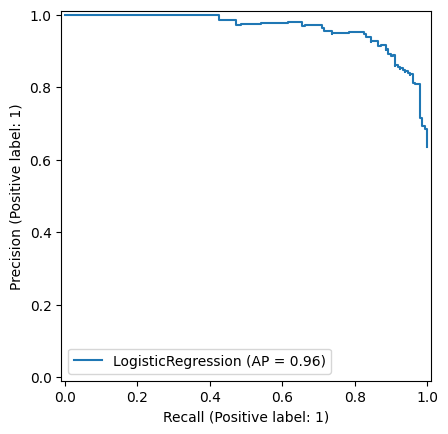

In [36]:
val_dict = df_val[numerical + categorical].to_dict(orient='records')
X_val = dv.transform(val_dict)

PrecisionRecallDisplay.from_estimator(model, X_val, y_val)

average precision = 0.96, which is a very good result even with a low predictive score of numerical variables.

In [37]:
df['converted'].mean()

np.float64(0.6190150478796169)

In [39]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

predict_positive = (y_pred >= 0.5)
predict_negative = (y_pred < 0.5)

tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()

fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

In [40]:
recall = tp / (fn + tp)
precision = tp / (tp + fp)

2 * ( recall * precision / (recall + precision) ) 

np.float64(0.8963210702341138)

Our F1-score is 89.6%

In [44]:
dv, model = train(df_full_train, df_full_train.converted.values, C=1.0)
y_pred = predict(df_test, dv, model)
roc_auc_score(y_test, y_pred)

0.8866562009419152